# Метод опорных векторов (SVM) — Breast Cancer Wisconsin

**Метод:** SVM строит гиперплоскость, максимально разделяющую классы; ядерный трюк (linear, polynomial, RBF) позволяет работать с нелинейными границами в исходном пространстве. SVM хорошо себя показывает на задачах с большим числом признаков и небольшим количеством объектов — это ровно случай Breast Cancer Wisconsin: 569 пациенток, 30 числовых характеристик опухоли, бинарная задача (M — злокачественная, B — доброкачественная).

## 1. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
)

## 2. Загрузка и просмотр датасета

In [2]:
df = pd.read_csv("data.csv")

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nПропуски по колонкам (всего):", df.isnull().sum().sum())

print("\nРаспределение diagnosis:")
print(df["diagnosis"].value_counts())

Размер датасета: (569, 32)

Первые 5 строк:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_wor

## 3. Предварительная обработка

In [3]:
data = df.copy()

# Удаляем id и пустую служебную колонку, если она есть
drop_cols = [c for c in ["id", "Unnamed: 32"] if c in data.columns]
data = data.drop(columns=drop_cols)

# Кодируем цель: M (злокач.) → 1, B (доброкач.) → 0
data["target"] = (data["diagnosis"] == "M").astype(int)
data = data.drop(columns=["diagnosis"])

print("Распределение target:")
print(data["target"].value_counts())

X = data.drop(columns=["target"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM чувствителен к масштабу — масштабируем
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train)
X_test_final  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Распределение target:
target
0    357
1    212
Name: count, dtype: int64

Train: (455, 30), Test: (114, 30)


## 4. Тепловая карта

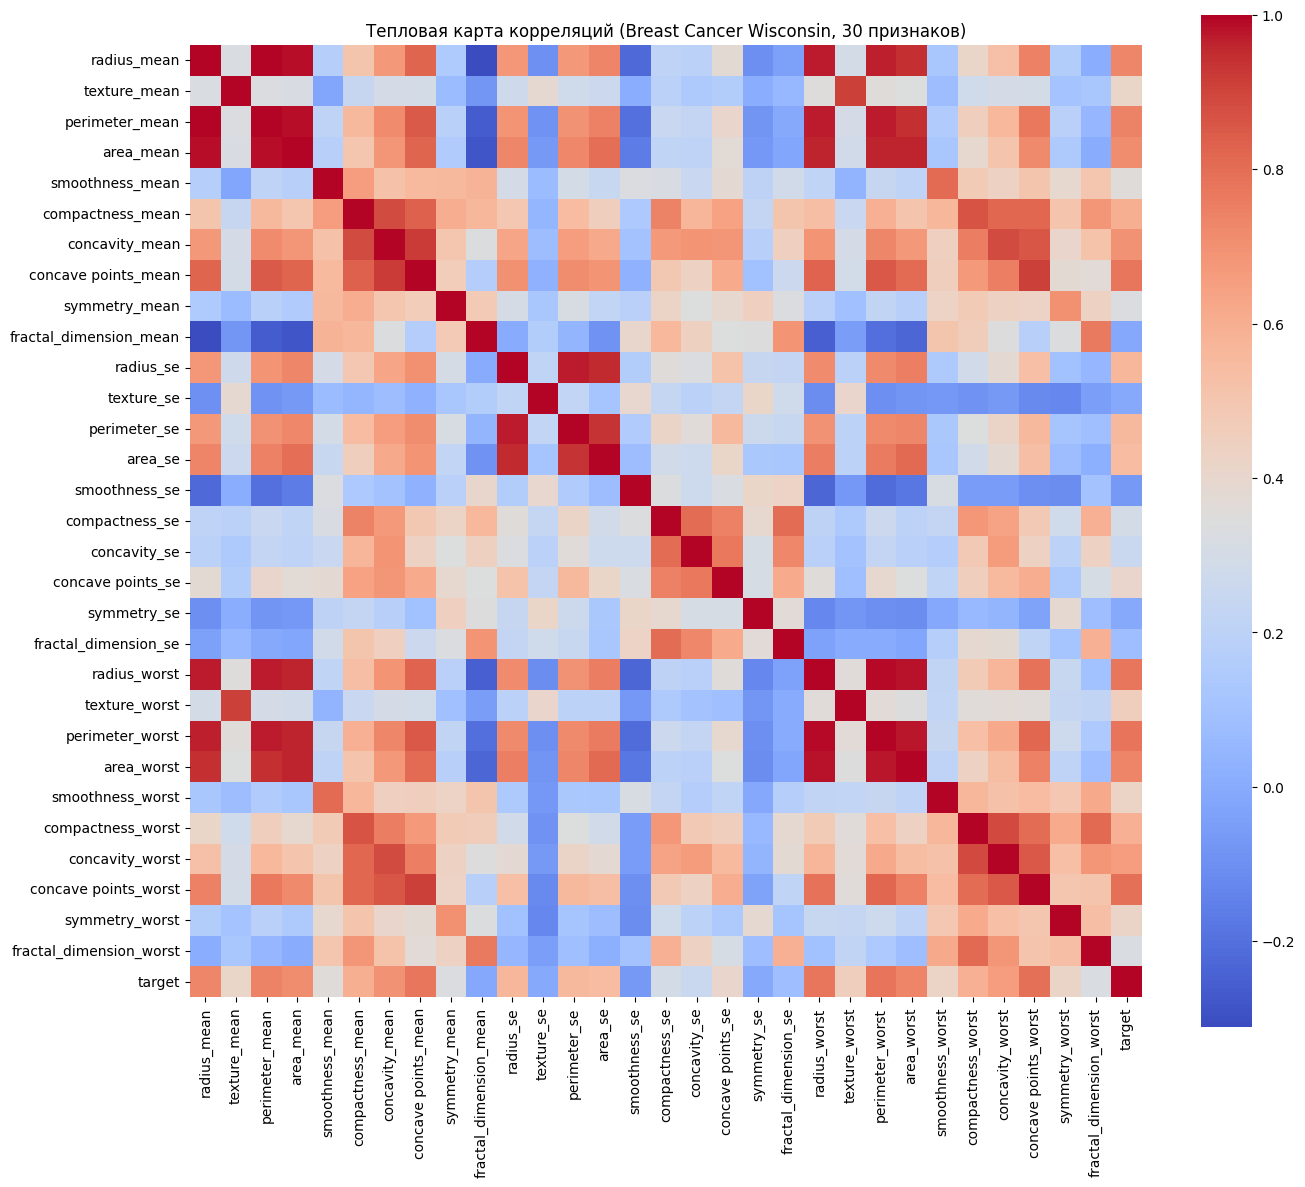

In [4]:
plt.figure(figsize=(14, 12))
sns.heatmap(data.corr(), annot=False, cmap="coolwarm", square=True)
plt.title("Тепловая карта корреляций (Breast Cancer Wisconsin, 30 признаков)")
plt.tight_layout()
plt.show()

## 5. Обучение модели

In [5]:
# Сравнение ядер на 5-fold CV
kernels = ["linear", "poly", "rbf"]
kernel_scores = {}
for k in kernels:
    clf = SVC(kernel=k, probability=True, random_state=42)
    scores = cross_val_score(clf, X_train_final, y_train, cv=5, scoring="f1")
    kernel_scores[k] = scores.mean()
    print(f"{k:>6}: F1 CV = {scores.mean():.4f}")

best_kernel = max(kernel_scores, key=kernel_scores.get)
print(f"\nЛучшее ядро: {best_kernel}")

model = SVC(kernel=best_kernel, probability=True, random_state=42)
model.fit(X_train_final, y_train)
print(f"Опорных векторов: {model.support_vectors_.shape[0]}")

linear: F1 CV = 0.9485
  poly: F1 CV = 0.8437
   rbf: F1 CV = 0.9670

Лучшее ядро: rbf
Опорных векторов: 107


## 6. Прогнозы модели

In [6]:
y_pred  = model.predict(X_test_final)
y_proba = model.predict_proba(X_test_final)[:, 1]

print("Первые 15 прогнозов:", y_pred[:15])
print("Реальные значения:  ", y_test.values[:15])

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["доброкач.", "злокач."]))

Первые 15 прогнозов: [0 1 0 0 0 0 1 0 0 0 1 0 1 0 0]
Реальные значения:   [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0]

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1-score:  0.9630
ROC-AUC:   0.9947

Classification report:
              precision    recall  f1-score   support

   доброкач.       0.96      1.00      0.98        72
     злокач.       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7. Графики выходных результатов

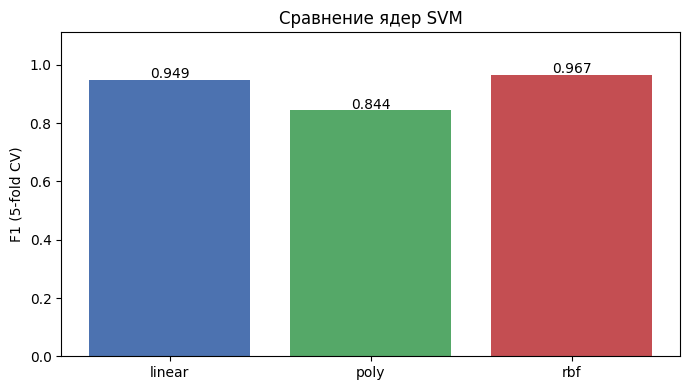

In [7]:
plt.figure(figsize=(7, 4))
ks = list(kernel_scores.keys())
vals = [kernel_scores[k] for k in ks]
bars = plt.bar(ks, vals, color=["#4C72B0", "#55A868", "#C44E52"])
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center")
plt.ylim(0, max(vals) * 1.15)
plt.ylabel("F1 (5-fold CV)")
plt.title("Сравнение ядер SVM")
plt.tight_layout()
plt.show()

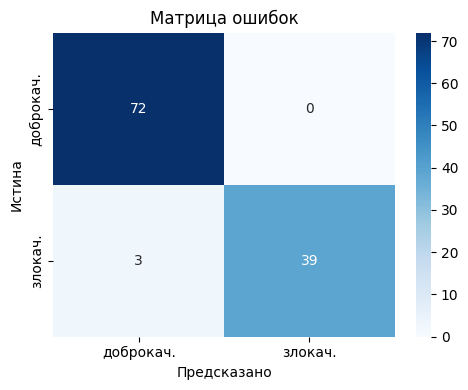

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["доброкач.", "злокач."],
            yticklabels=["доброкач.", "злокач."])
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

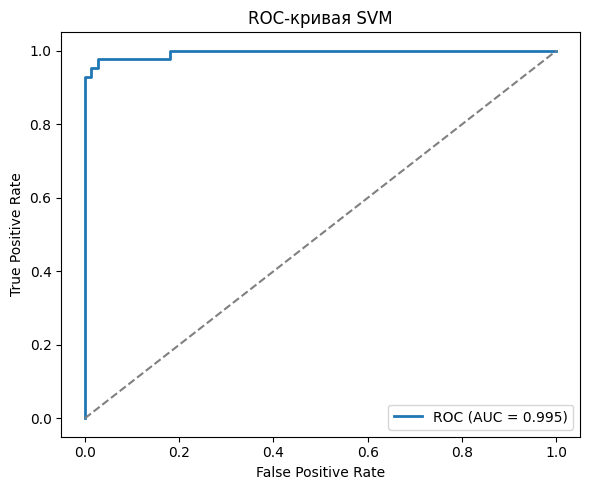

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая SVM")
plt.legend()
plt.tight_layout()
plt.show()

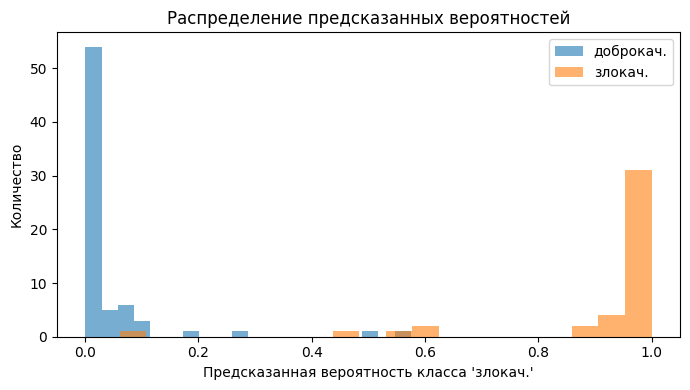

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.6, label="доброкач.")
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.6, label="злокач.")
plt.xlabel("Предсказанная вероятность класса 'злокач.'")
plt.ylabel("Количество")
plt.title("Распределение предсказанных вероятностей")
plt.legend()
plt.tight_layout()
plt.show()